# Lab 06: Species Distribution Models From First Principles

## BIO597 Spatial Analysis of Biodiversity

This lab builds a deliberately simple species distribution model using one environmental variable. The goal is not to create a publishable SDM. The goal is to see the core idea: occurrence records describe the environments where a species has been observed, and an SDM projects that environmental association across unsampled places.

We will use annual mean temperature, one amphibian species, and a hand-built suitability score. By the end, you should be able to explain what a package such as Maxent, biomod2, dismo, or sdm is doing at a conceptual level before we ask those packages to do more complicated work.

## Lesson structure

* Frame the SDM question and choose a species
* Extract one environmental variable at occurrence locations
* Compare presence environments with background environments
* Build a simple suitability curve by hand
* Project the suitability curve as a map and interpret it
* Discuss assumptions, bias, and what a full SDM adds

## Conceptual model

A species distribution model links three things:

1. **Occurrences:** places where the species has been recorded.
2. **Predictors:** environmental values measured across space.
3. **Projection:** a map estimating where similar environmental conditions occur.

Today we will use this simple rule:

> Places are more suitable when their annual mean temperature is close to the average annual mean temperature at known occurrence records.

This is a useful sketch, but it is not a complete ecological model. It ignores detection, sampling bias, dispersal, biotic interactions, spatial autocorrelation, and every environmental variable except temperature.

## 1. Import packages

We will use the same spatial tools from earlier labs plus `numpy` and `matplotlib` for simple computation and plotting.

In [ ]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray as rxr
import xarray as xr

## 2. Load and prepare the Maine boundary

We will use the Maine boundary to clip the climate raster to our study area.

In [ ]:
maine_boundary = gpd.read_file("ME_ShapeFiles/Maine_State_Boundary.shp")
print(maine_boundary.shape)
print(maine_boundary.crs)

maine_boundary = maine_boundary.dissolve()
maine_boundary.explore()

## 3. Open annual mean temperature

BIO1 is annual mean temperature from WorldClim. Depending on how the file was stored, temperature may be represented directly in degrees Celsius or as tenths of degrees Celsius. The next cell uses a simple check so our map and calculations are in degrees Celsius.

In [ ]:
bioclim_path = Path("/home/jovyan/shared-readwrite/bioclim")
#bioclim_path = Path("./bioclim")
bio1 = rxr.open_rasterio(
    bioclim_path / "wc2.1_2.5m_bio_1.tif",
    masked=True,
)

bio1_maine = bio1.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
).squeeze()

if float(bio1_maine.max()) > 100:
    bio1_maine_c = bio1_maine / 10
else:
    bio1_maine_c = bio1_maine

bio1_maine_c.name = "annual_mean_temperature_c"
bio1_maine_c

## 4. Map the predictor

Before modeling anything, always look at the environmental layer. An SDM can only learn patterns that are represented in its predictors.

In [ ]:
bio1_maine_c.plot(cmap="coolwarm")
plt.title("Annual mean temperature in Maine")
plt.show()

## 5. Load occurrence records

We will use the same Maine amphibian occurrence records from earlier assignments.

In [ ]:
amphibians = pd.read_csv(
    "../assignments/Amphibians_ME/Amphibians_ME.csv",
    sep="\t",
    low_memory=False,
)

columns_to_keep = [
    "gbifID",
    "species",
    "decimalLongitude",
    "decimalLatitude",
    "coordinateUncertaintyInMeters",
    "year",
]

amphibians = amphibians[columns_to_keep].copy()
amphibians["decimalLongitude"] = pd.to_numeric(amphibians["decimalLongitude"], errors="coerce")
amphibians["decimalLatitude"] = pd.to_numeric(amphibians["decimalLatitude"], errors="coerce")

# Simple cleaning
amphibians = amphibians.dropna(subset=["species", "decimalLongitude", "decimalLatitude"]).copy()

# Reduce spatial imprecision (The "tulipifera-ike" filter!)
amphibians = amphibians[amphibians["coordinateUncertaintyInMeters"] < 200]

amphibians["species"].value_counts().head(12)

## 6. Choose one species

For the lab we will use **Boreorana sylvatica**, the wood frog. It has many records in this dataset and occurs across a broad part of Maine, which makes it useful for a first SDM exercise.

You can change `target_species` to another species with enough records if you want to compare results.

In [ ]:
target_species = "Boreorana sylvatica"

presence = amphibians.loc[amphibians["species"] == target_species].copy()
print(target_species)
print(presence.shape)
presence.head()

## 7. Create occurrence points

The climate raster and occurrence points both use longitude and latitude, so we can extract values directly after confirming their coordinate reference systems.

In [ ]:
presence_gdf = gpd.GeoDataFrame(
    presence,
    geometry=gpd.points_from_xy(
        presence["decimalLongitude"],
        presence["decimalLatitude"],
    ),
    crs="EPSG:4326",
)

print("Occurrence CRS:", presence_gdf.crs)
print("Raster CRS:", bio1_maine_c.rio.crs)

presence_gdf.explore()

## 8. Extract temperature at occurrences

Each occurrence point is assigned the temperature value from the nearest raster cell.

In [ ]:
point_x = xr.DataArray(presence_gdf.geometry.x.values, dims="record")
point_y = xr.DataArray(presence_gdf.geometry.y.values, dims="record")

presence_temp = bio1_maine_c.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

presence_gdf["bio1_c"] = presence_temp.values
presence_gdf = presence_gdf.dropna(subset=["bio1_c"]).copy()

# Rebuild these after dropping missing raster values so later extractions align.
point_x = xr.DataArray(presence_gdf.geometry.x.values, dims="record")
point_y = xr.DataArray(presence_gdf.geometry.y.values, dims="record")

presence_gdf[["species", "decimalLongitude", "decimalLatitude", "bio1_c"]].head()

## 9. Summarize the presence environment

This is the simplest possible environmental description of the species records.

In [ ]:
presence_mean = presence_gdf["bio1_c"].mean()
presence_sd = presence_gdf["bio1_c"].std()

print(f"Number of usable records: {len(presence_gdf)}")
print(f"Mean occurrence temperature: {presence_mean:.2f} C")
print(f"SD of occurrence temperature: {presence_sd:.2f} C")
print(f"Minimum occurrence temperature: {presence_gdf['bio1_c'].min():.2f} C")
print(f"Maximum occurrence temperature: {presence_gdf['bio1_c'].max():.2f} C")

## 10. Sample the background environment

Occurrence records alone do not tell us what conditions are available in the study area. A background sample represents the environments that occur across Maine.

This is not absence data. It is a sample of available environments.

In [ ]:
rng = np.random.default_rng(597)

valid_temperature = bio1_maine_c.values
valid_temperature = valid_temperature[np.isfinite(valid_temperature)]

background_temp = rng.choice(
    valid_temperature,
    size=min(5000, valid_temperature.size),
    replace=False,
)

print(f"Background sample size: {len(background_temp)}")
print(f"Mean background temperature: {background_temp.mean():.2f} C")
print(f"SD background temperature: {background_temp.std():.2f} C")

## 11. Compare presence and background temperatures

If a species uses environments randomly with respect to temperature, the presence histogram should look like the background histogram. If occurrences are concentrated in a subset of available temperatures, that suggests a temperature association.

In [ ]:
plt.hist(background_temp, bins=30, alpha=0.5, density=True, label="Background")
plt.hist(presence_gdf["bio1_c"], bins=30, alpha=0.6, density=True, label="Occurrences")
plt.axvline(presence_mean, color="black", linestyle="--", label="Occurrence mean")
plt.xlabel("Annual mean temperature (C)")
plt.ylabel("Density")
plt.title(f"Temperature environments for {target_species}")
plt.legend()
plt.show()

## 12. Build a suitability curve

Here is our first-principles model. We assign each temperature a suitability score between 0 and 1.

The score is highest at the mean occurrence temperature. It declines as temperature gets farther from that mean. The standard deviation of occurrence temperatures controls how quickly the score declines.

This is similar in spirit to saying: "the species is most associated with environments like the ones where we have observed it."

In [ ]:
def temperature_suitability(temperature, optimum, tolerance):
    z = (temperature - optimum) / tolerance
    return np.exp(-0.5 * z**2)

x_temp = np.linspace(
    float(np.nanmin(bio1_maine_c.values)),
    float(np.nanmax(bio1_maine_c.values)),
    200,
)

suitability_curve = temperature_suitability(
    x_temp,
    optimum=presence_mean,
    tolerance=presence_sd,
)

plt.plot(x_temp, suitability_curve)
plt.axvline(presence_mean, color="black", linestyle="--", label="Occurrence mean")
plt.xlabel("Annual mean temperature (C)")
plt.ylabel("Suitability score")
plt.ylim(0, 1.05)
plt.title("A hand-built temperature suitability curve")
plt.legend()
plt.show()

## 13. Project the suitability curve across Maine

Now we apply the same equation to every raster cell. This is the projection step: each place gets a suitability score based on its annual mean temperature.

In [ ]:
suitability = xr.apply_ufunc(
    temperature_suitability,
    bio1_maine_c,
    presence_mean,
    presence_sd,
)

suitability = suitability.where(np.isfinite(bio1_maine_c))
suitability = suitability.rio.write_crs(bio1_maine_c.rio.crs)
suitability.name = "temperature_suitability"
suitability

## 14. Map predicted suitability

This is our first-principles SDM map. It is not a probability of presence. It is a relative score based on similarity to the occurrence temperature profile.

In [ ]:
suitability.plot(vmin=0, vmax=1, cmap="viridis")
plt.title(f"Temperature-based suitability for {target_species}")
plt.show()

## 15. Overlay occurrences on the suitability map

A basic visual check asks whether occurrence records tend to fall in areas that the model scores highly.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
suitability.plot(ax=ax, vmin=0, vmax=1, cmap="viridis")
presence_gdf.plot(ax=ax, markersize=6, color="white", edgecolor="black", linewidth=0.2)
ax.set_title(f"Occurrences over temperature suitability for {target_species}")
plt.show()

## 16. Extract suitability at occurrence and background locations

A model should usually score known occurrences higher than random background locations. This check is rough, but it helps us see what the model is doing.

In [ ]:
presence_suitability = suitability.sel(
    x=point_x,
    y=point_y,
    method="nearest",
).values

background_suitability = temperature_suitability(
    background_temp,
    optimum=presence_mean,
    tolerance=presence_sd,
)

print(f"Mean occurrence suitability: {np.nanmean(presence_suitability):.3f}")
print(f"Mean background suitability: {np.nanmean(background_suitability):.3f}")

plt.hist(background_suitability, bins=30, alpha=0.5, density=True, label="Background")
plt.hist(presence_suitability, bins=30, alpha=0.6, density=True, label="Occurrences")
plt.xlabel("Suitability score")
plt.ylabel("Density")
plt.title("Suitability scores at occurrences and background cells")
plt.legend()
plt.show()

## 17. Try a stricter or broader tolerance

The tolerance parameter controls how broad the predicted suitable area is. Full SDM methods estimate relationships from data, but they still make choices that affect how broad or narrow predictions become.

In [ ]:
narrow_suitability = xr.apply_ufunc(
    temperature_suitability,
    bio1_maine_c,
    presence_mean,
    presence_sd / 2,
).where(np.isfinite(bio1_maine_c))

broad_suitability = xr.apply_ufunc(
    temperature_suitability,
    bio1_maine_c,
    presence_mean,
    presence_sd * 2,
).where(np.isfinite(bio1_maine_c))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
narrow_suitability.plot(ax=axes[0], vmin=0, vmax=1, cmap="viridis")
axes[0].set_title("Narrow tolerance")
suitability.plot(ax=axes[1], vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Observed SD tolerance")
broad_suitability.plot(ax=axes[2], vmin=0, vmax=1, cmap="viridis")
axes[2].set_title("Broad tolerance")
plt.tight_layout()
plt.show()

## 18. Convert continuous suitability to a binary map

Many SDM products are eventually converted into "suitable" and "unsuitable" areas. This threshold step is common, but it is also a major modeling choice.

Here we use a simple threshold: cells with suitability of at least 0.5 are labeled suitable.

In [ ]:
threshold = 0.5
suitable_binary = suitability >= threshold
suitable_binary = suitable_binary.where(np.isfinite(bio1_maine_c))

suitable_binary.plot(cmap="Greens")
plt.title(f"Cells with suitability >= {threshold}")
plt.show()

suitable_fraction = float(suitable_binary.mean(skipna=True))
print(f"Fraction of Maine climate cells labeled suitable: {suitable_fraction:.2%}")

## 19. Save the conceptual SDM outputs

Saving the raster lets us inspect it later or compare it with future models.

In [ ]:
suitability.rio.to_raster("Lab06_temperature_suitability.tif")

presence_table = presence_gdf.drop(columns="geometry")
presence_table["temperature_suitability"] = presence_suitability
presence_table.to_csv("Lab06_presence_temperature_suitability.csv", index=False)

## 20. Additional activities

Before you do each of these exercises think about what will happen when you do it:
* Use only 50 background points and re-run up to the mapping step (step 14).
* Sample background only from one side of the study area.
* Remove occurrences from the hottest part of the range.
* Change the temperature bin width.

## Discussion questions

1. What ecological assumption is made when suitability is highest near the mean occurrence temperature?
2. Why is background environment different from true absence data?
3. How did changing the tolerance affect the size and location of predicted suitable areas?
4. Why should this map not be interpreted as probability of occurrence?
5. What important predictors or processes are missing from this one-variable model?
6. What parts of this workflow do full SDM packages automate or extend?

## Submit your work to GitHub

Run the notebook from top to bottom. Save it, then add, commit, and push the notebook from a terminal.

```bash
git add docs/labs/Lab06-FirstPrinciplesSDM.ipynb
git commit -m "Complete first principles SDM lab"
git push
```

[-0.1         1.02222222  2.14444444  3.26666667  4.38888889  5.51111111
  6.63333333  7.75555556  8.87777778 10.        ]


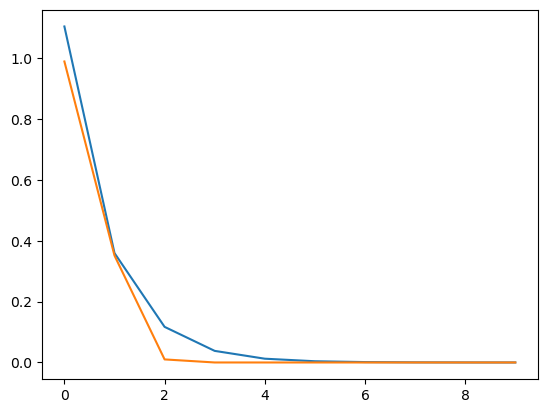

In [57]:
vals = np.linspace(-0.1, 10, num=10)
print(vals)
plt.plot(np.exp(-vals))
plt.plot(np.exp(-vals**2))